1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

The final number of Thallium atoms is 1


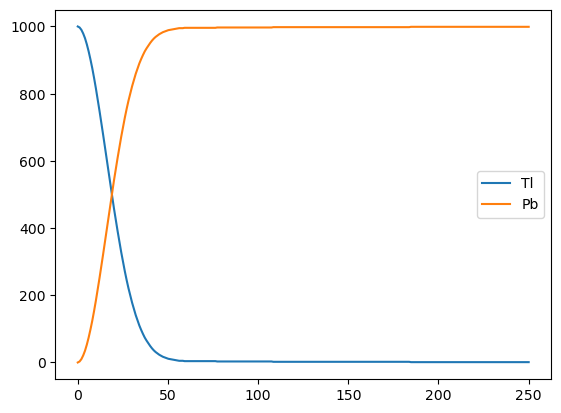

/var/folders/6w/vv6mxd6s5tn2fg5xf8lytbl40000gp/T/ipykernel_52423/4290223910.py:25: RuntimeWarning: invalid value encountered in log2
  return -np.log2(1-x/tau)*np.log2(2)/tau


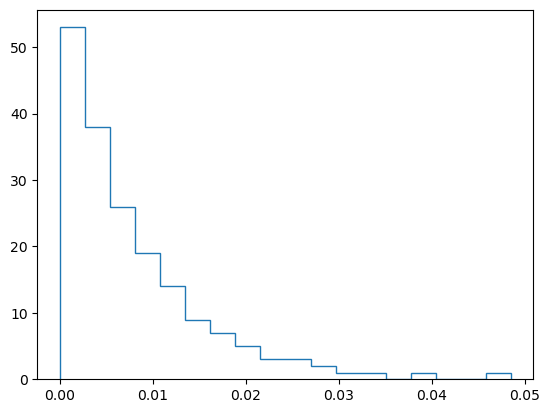

In [3]:
import numpy as np
import matplotlib.pyplot as plt

tau = 3.052*60
T = 250
Tl = 1000
Tl_a = []
Pb_a = []
for t in range(T):
    Tl -= int((1-2**(-t/tau))*Tl)
    Tl_a.append(Tl)
    Pb_a.append(1000-Tl)
    
x = np.linspace(0,T,T)
plt.plot(x,Tl_a, label ="Tl")
plt.plot(x,Pb_a, label ="Pb")
plt.legend()
print(f"The final number of Thallium atoms is {int(Tl)}")
plt.show()

def p(t, tau = tau):
    return 2**(-t/tau)*(np.log2(2)/tau)

def inv_p(t, tau=tau):
    return -np.log2(1-x/tau)*np.log2(2)/tau

u = np.random.random(10000)
v = inv_p(u)
plt.hist(v, histtype='step', bins = 18)
plt.show()

2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

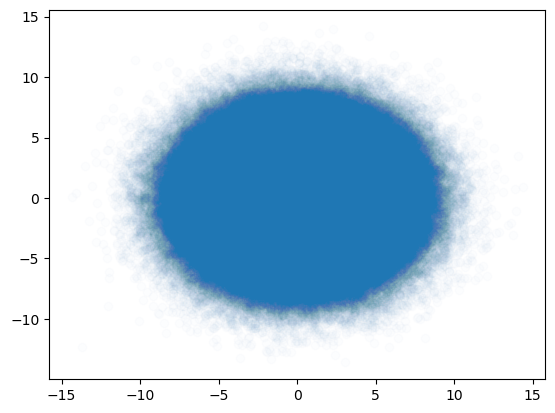

The fraction of particles that bounce back is 62.1%


In [109]:
E = 7.7
a0 = 300
n = 1000000
d = [np.random.normal(0,a0/100,n),np.random.normal(0,a0/100,n)]
plt.scatter(d[0],d[1], alpha=0.01)
d = np.array(d).T
th = np.array([(2*np.arctan(79*1.6**2/(2*np.pi*E*(np.sqrt(b[0]**2+b[1]**2))))) for b in d])
mask = th > np.ones(len(th))*np.pi/2
bb = th[mask]
plt.show()
print(f"The fraction of particles that bounce back is {round(len(bb)/n*100,2)}%")

3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

The integral of the function f(x) calculated via hit/miss method is : 1.4487
The integral calculated with Montecarlo integration method is : 1.45106
The integral calculated with mean method is : 1.4514


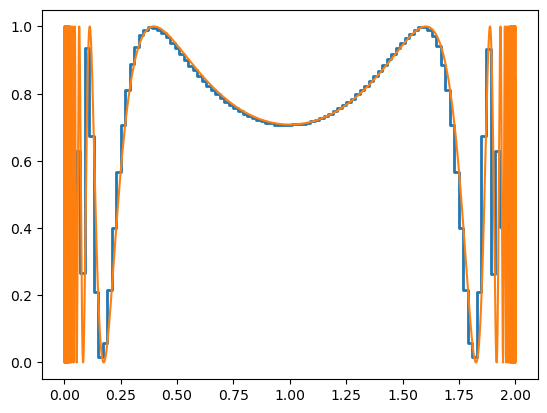

In [5]:
%precision 2

def f(x):
    return (np.sin(1/(x*(2-x))))**2

def g(x):
    return 1

n = 100000000
x = np.linspace(0.0001,1.9999,n)
u = np.random.uniform(0.0001, 1.9999, n)
r = np.random.uniform(0, 1, n)
a = u[r < f(u)]

hist, bin_edges = np.histogram(a, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
fact = f(1)/hist[int(100/2)]
plt.step(bin_centers, hist*fact, linewidth=2)
plt.plot(x, f(x))
b = np.min(np.diff(bin_centers))
print(f"The integral of the function f(x) calculated via hit/miss method is :", round(np.sum(hist*b)*fact,4))
N=100000
count=0
for i in range(N):
    x_1=2*np.random.random()
    y=np.random.random()
    if y<f(x_1): count+=1
I=2*count/N
print("The integral calculated with Montecarlo integration method is :", I)

M = 2/n*np.sum(f(x))
print("The integral calculated with mean method is :", round(M,4))
plt.show()

4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere



The Area of the circle of radious 1 is : 3.13804
The volume of a 5 dimensional sphear is : 5.2352


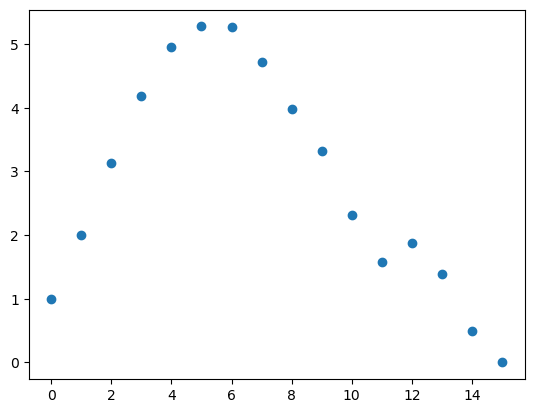

In [157]:
def q(x,y):
    r = 0
    if (x**2+y**2) <= 1:
        r = 1
    return r

N=100000
count=0
for i in range(N):
    x=(2*np.random.random())-1
    y=(2*np.random.random())-1
    c = np.random.random()
    if c < q(x,y): count+=1
I=2**2*count/N
print("The Area of the circle of radious 1 is :",I)

def vol_n_dim_sphere(d):
    N = 100000
    count = 0
    
    def n_random(d):
        var = (2*np.random.random(d))-np.ones(d)
        return var
    
    def in_sph(var):
        r = 0
        if np.sum(var**2) <= 1:
            r = 1
        return r
    
    for i in range(N):
        var1 = n_random(d)
        c = np.random.random()
        if c < in_sph(var1): count += 1

    I = 2**d*count/N
    
    return I

dim = 5

print(f"The volume of a {dim} dimensional sphear is : {vol_n_dim_sphere(dim)}")

volumes = [(vol_n_dim_sphere(i)) for i in range(16)]
plt.scatter(range(16),volumes)

5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [275]:
def f(x):
    return (x**(-1/2)/((np.e**x)+1))

def w(x):
    return 1/np.sqrt(x)

N = 100000900

x = np.random.random(N)**2

I = np.array(f(x)/w(x)).mean()*2

print(round(I,9))

0.838927965
